In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df=pd.read_csv('feature_selection.csv')

In [4]:
df.sample(5)

,society,price,price_persqft,bedRoom,bathroom,balcony,floorNum,agePossession,sector,type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3524,ansal sushant lok plots,11.50,17692.0,7.0,8.0,3+,3.0,Old Property,sector 43,house,6500.0,0,1,1,1,0,0,31
889,pyramid urban homes 2,0.42,8283.0,2.0,2.0,1,7.0,New Property,sector 86,flat,501.0,1,1,0,1,1,2,49
1372,ss the leaf,1.07,6524.0,2.0,2.0,3,21.0,Relatively New,sector 85,flat,1312.0,0,0,0,1,0,2,67
2345,satya element one,0.87,19333.0,1.0,1.0,1,2.0,Relatively New,sector 49,flat,450.0,0,0,0,0,0,2,22
2179,nbcc heights,0.75,6578.0,2.0,2.0,2,6.0,Moderately Old,sector 89,flat,912.0,0,0,0,0,0,2,0


In [5]:
train_df=df.drop(columns=['price_persqft','society'],axis=1)

In [6]:
train_df.sample(5)

,price,bedRoom,bathroom,balcony,floorNum,agePossession,sector,type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3082,1.05,3.0,2.0,0,1.0,Moderately Old,sector 11,house,1076.0,0,0,0,0,0,2,0
801,3.46,4.0,4.0,3+,10.0,New Property,sector 81,flat,2297.6,0,1,0,0,0,1,161
2413,0.55,2.0,2.0,0,5.0,Relatively New,samaspur,flat,1050.0,0,0,0,0,0,2,36
1695,0.69,2.0,2.0,3+,8.0,Relatively New,sector 84,flat,1080.0,1,0,0,0,0,2,59
3237,5.60,4.0,3.0,3+,3.0,Moderately Old,g block dlf city phase 1,house,1797.0,0,0,0,0,0,2,33


# --------------------------------------------------

In [7]:
train_df.shape

(3709, 16)

<Axes: >

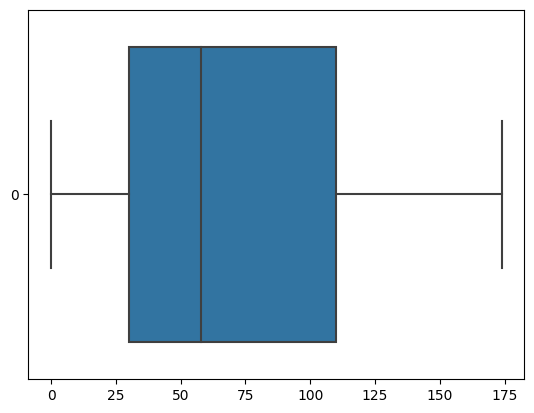

In [8]:
sns.boxplot(train_df['luxury_score'],orient='h')

In [9]:
print(train_df['luxury_score'].quantile(0.25))
print(train_df['luxury_score'].quantile(0.50))
print(train_df['luxury_score'].quantile(0.75))

30.0
58.0
110.0


In [10]:
def categorize_luxury(score):
    if 0 <= score < 30:
        return "Low"
    elif 30 <= score < 58:
        return "Normal"
    elif 58 <= score <= 110:
        return "semi_luxrious"
    elif score>110:
        return 'luxrious'
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [11]:
train_df['luxury']=train_df['luxury_score'].apply(categorize_luxury)

In [12]:
train_df['luxury'].value_counts()

luxury
semi_luxrious    953
Normal           937
Low              916
luxrious         903
Name: count, dtype: int64

In [13]:
train_df.head(5)

,price,bedRoom,bathroom,balcony,floorNum,agePossession,sector,type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury
0,0.45,2.0,2.0,1,4.0,Relatively New,sector 7,flat,900.0,0,0,0,0,0,2,28,Low
1,0.50,2.0,2.0,1,1.0,Old Property,sector 3,flat,650.0,0,0,0,0,0,0,37,Normal
2,0.40,2.0,2.0,3,12.0,New Property,sohna road,flat,595.0,0,0,0,0,0,2,36,Normal
3,1.47,2.0,2.0,2,2.0,New Property,sector 61,flat,1200.0,1,0,0,0,0,2,76,semi_luxrious
4,0.70,2.0,2.0,3,5.0,Under Construction,sector 92,flat,1076.0,1,0,0,0,0,2,0,Low


<Axes: >

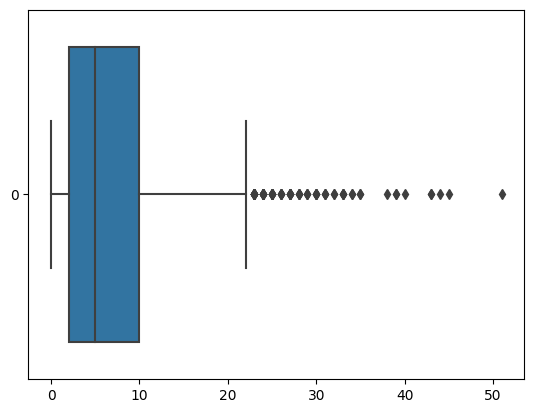

In [14]:
sns.boxplot(train_df['floorNum'],orient='h')

In [15]:
train_df['floorNum'].quantile(0.25)

2.0

<Axes: xlabel='floorNum', ylabel='Count'>

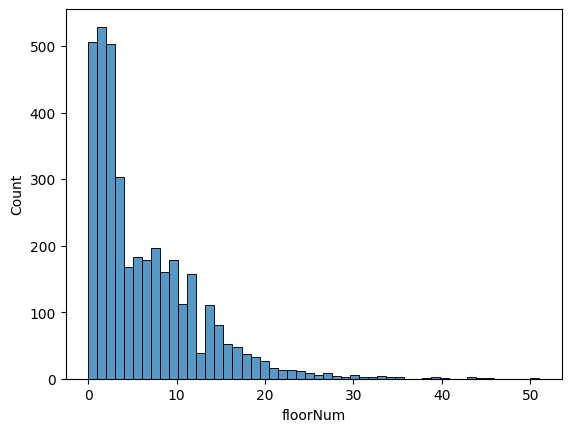

In [16]:
sns.histplot(train_df['floorNum'])

In [17]:
temp=train_df[train_df['floorNum']>15]

In [18]:
train_df['built_up_area'].quantile(0.90)

2841.0

In [19]:
train_df['built_up_area'].quantile(0.75)

1975.052

In [20]:
tt=temp[(temp['luxury']=='luxrious')&(temp['built_up_area']>2500)]

In [21]:
tt['floorNum']='hometop'

/var/folders/9h/szcjr1mj4c51q1_y7hpk6bvm0000gn/T/ipykernel_39571/109175259.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tt['floorNum']='hometop'


In [22]:
temp.update(tt)

In [23]:
temp.sample(5)

,price,bedRoom,bathroom,balcony,floorNum,agePossession,sector,type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury
631,1.25,3.0,3.0,3,18.0,Relatively New,sector 79,flat,863.910614,1,0,0,0,0,0,102,semi_luxrious
2562,3.25,4.0,4.0,3+,34.0,New Property,sector 113,flat,2298.000000,1,1,0,1,0,2,115,luxrious
3038,8.50,4.0,4.0,3+,27.0,New Property,sector 63,house,3948.920000,0,0,0,0,0,2,61,semi_luxrious
726,3.40,3.0,4.0,3+,16.0,Relatively New,sector 67,flat,1886.400000,0,1,0,0,0,0,158,luxrious
171,2.00,4.0,4.0,3+,16.0,Moderately Old,sector 91,flat,2181.600000,1,1,0,1,0,2,65,semi_luxrious


In [24]:
temp.shape

(304, 17)

In [25]:
train_df.update(temp)

In [26]:
ter=train_df[train_df['floorNum']!='hometop']

In [27]:
ter.sample(5)

,price,bedRoom,bathroom,balcony,floorNum,agePossession,sector,type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury
1815,0.85,3.0,3.0,3+,4.0,Relatively New,sector 1,flat,1840.0,0,1,0,0,0,2,5,Low
358,4.25,3.0,4.0,3+,3.0,Old Property,sector 24,flat,3200.0,0,1,1,0,0,0,131,luxrious
2464,1.90,3.0,3.0,3,10.0,New Property,sector 70,flat,1560.0,0,1,1,1,1,2,36,Normal
1378,1.23,2.0,2.0,3,13.0,Relatively New,sector 86,flat,1184.0,1,0,0,0,0,2,6,Low
1563,0.50,3.0,2.0,2,5.0,Relatively New,sector 107,flat,645.0,0,0,0,0,1,2,35,Normal


<Axes: >

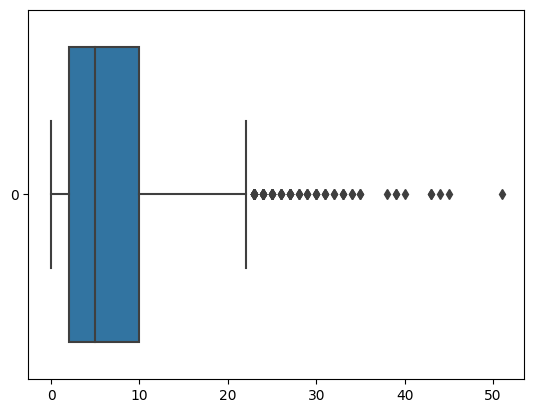

In [28]:
sns.boxplot(ter['floorNum'],orient='h')

In [29]:
print(ter['floorNum'].quantile(0.25))
print(ter['floorNum'].quantile(0.5))
print(ter['floorNum'].quantile(0.75))
print(ter['floorNum'].quantile(0.9))

2.0
5.0
10.0
14.0


In [30]:
def categorize_floor(floor):
    if floor==0:
        return 'groundfloor'
    if 0 < floor < 5:
        return "Low Floor"
    elif 5 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None

In [31]:
ter['floorNum']=ter['floorNum'].apply(categorize_floor)

/var/folders/9h/szcjr1mj4c51q1_y7hpk6bvm0000gn/T/ipykernel_39571/926870377.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ter['floorNum']=ter['floorNum'].apply(categorize_floor)


In [32]:
ter['floorNum'].value_counts()

floorNum
Low Floor      1708
Mid Floor      1064
High Floor      787
groundfloor     133
Name: count, dtype: int64

In [33]:
ter[ter['floorNum']=='groundfloor']['price'].describe()

count    133.000000
mean       1.567218
std        1.392942
min        0.130000
25%        0.740000
50%        1.200000
75%        1.900000
max        7.250000
Name: price, dtype: float64

In [34]:
ter[ter['floorNum']=='groundfloor']['built_up_area'].describe()

count     133.000000
mean     1458.793797
std      1030.951642
min        72.000000
25%       788.000000
50%      1262.400000
75%      1785.000000
max      8136.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='floorNum', ylabel='price'>

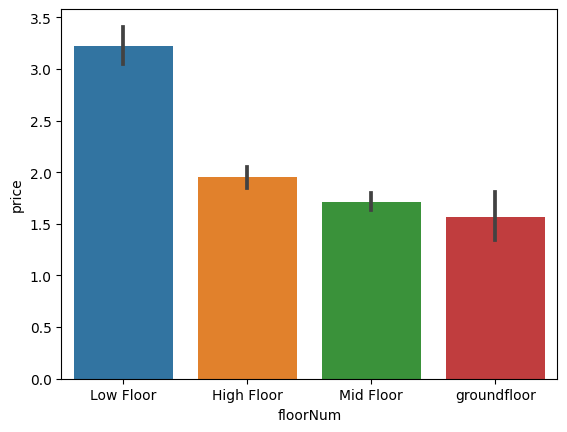

In [35]:
sns.barplot(data=ter,x='floorNum',y='price')

<Axes: xlabel='floorNum', ylabel='built_up_area'>

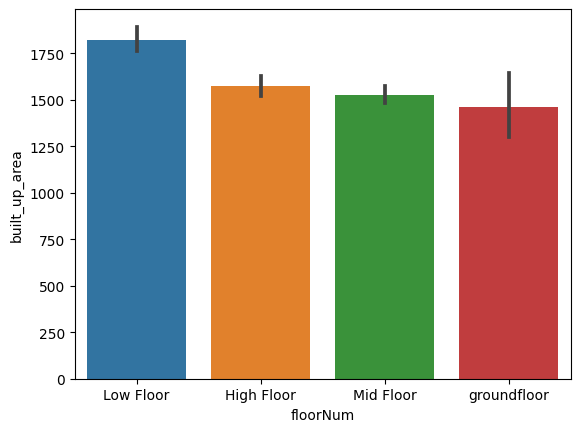

In [36]:
sns.barplot(data=ter,x='floorNum',y='built_up_area')

trend is same so this approch may be right

In [37]:
train_df.update(ter)

In [38]:
train_df['floorNum'].value_counts()

floorNum
Low Floor      1708
Mid Floor      1064
High Floor      787
groundfloor     133
hometop          17
Name: count, dtype: int64

<Axes: xlabel='floorNum', ylabel='price'>

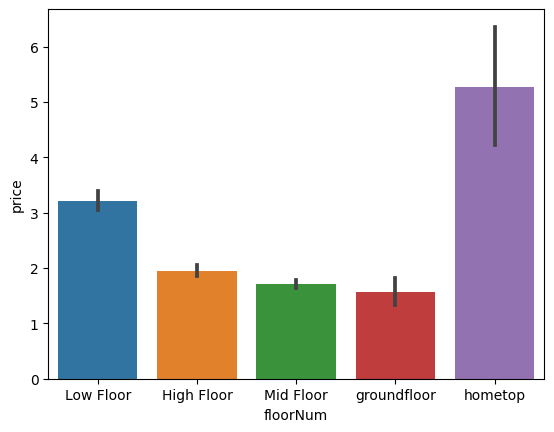

In [39]:
sns.barplot(data=train_df,x='floorNum',y='price')

In [40]:
train_df.sample(5)

,price,bedRoom,bathroom,balcony,floorNum,agePossession,sector,type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury
2776,1.00,3.0,4.0,0,Low Floor,New Property,sector 1,flat,2479.544,0,0,0,0,0,2,0,Low
3396,12.50,4.0,4.0,3+,Low Floor,Relatively New,sector 65,house,3595.000,1,1,0,0,0,2,56,Normal
2912,5.70,4.0,5.0,3+,Low Floor,Relatively New,sector 109,house,5403.000,1,1,1,1,0,2,160,luxrious
3196,4.30,6.0,4.0,2,Low Floor,Moderately Old,sector 47,house,1464.000,0,0,0,0,1,2,0,Low
1960,3.35,3.0,3.0,3+,Low Floor,New Property,sector 63,flat,1627.200,0,0,0,0,0,0,16,Low


In [41]:
train_df.rename(columns={'floorNum':'floor_type'},inplace=True)

In [42]:
train_df.drop(columns='luxury_score',axis=1,inplace=True)

<Axes: xlabel='floor_type', ylabel='built_up_area'>

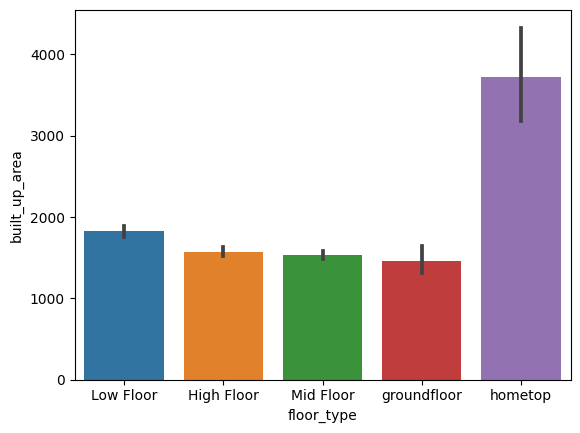

In [43]:
sns.barplot(data=train_df,x='floor_type',y='built_up_area')

In [44]:
''' balcony 3+ treat like a different category '''
train_df.columns
   

Index(['price', 'bedRoom', 'bathroom', 'balcony', 'floor_type',
       'agePossession', 'sector', 'type', 'built_up_area', 'study room',
       'servant room', 'store room', 'pooja room', 'others', 'furnishing_type',
       'luxury'],
      dtype='object')

'''(floor_type ,agePossession, type, luxury) -->encoding
     floor_type-->ordinal encoding
      agepossesion-->            ,
      type-->one hot encoding
      luxury-->ordinal encoding'''

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Relatively New'),
  Text(1, 0, 'Old Property'),
  Text(2, 0, 'New Property'),
  Text(3, 0, 'Under Construction'),
  Text(4, 0, 'Moderately Old')])

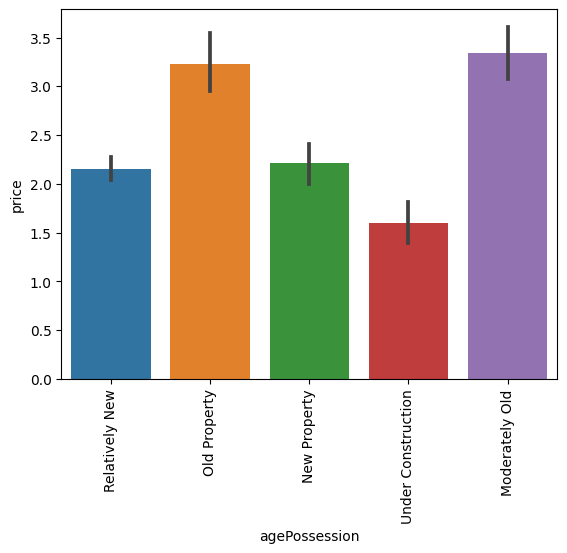

In [45]:
sns.barplot(data=train_df,x='agePossession',y='price')
plt.xticks(rotation=90)

In [46]:
train_df = train_df.sample(frac=1).reset_index(drop=True)

In [47]:
train_df.sample(5)

,price,bedRoom,bathroom,balcony,floor_type,agePossession,sector,type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury
1679,1.15,3.0,4.0,3,Mid Floor,Relatively New,sector 106,flat,1173.00,1,1,0,0,0,2,Normal
768,0.95,2.0,2.0,1,Low Floor,Relatively New,sector 2,flat,990.00,0,0,0,0,0,2,semi_luxrious
1597,0.75,3.0,3.0,3,Mid Floor,New Property,sector 83,flat,1000.00,0,0,0,0,1,0,Normal
3064,1.80,4.0,5.0,0,High Floor,Relatively New,sector 92,house,2356.44,0,0,0,0,0,2,Low
23,0.65,2.0,2.0,3,groundfloor,New Property,sector 37d,flat,650.00,0,0,0,0,0,2,Normal


In [49]:
train_df['floor_type']=train_df['floor_type'].str.lower()
train_df['luxury']=train_df['luxury'].str.lower()

In [50]:
train_df['floor_type'].unique()

array(['high floor', 'low floor', 'mid floor', 'groundfloor', 'hometop'],
      dtype=object)

In [51]:
train_df['luxury'].unique()

array(['semi_luxrious', 'luxrious', 'normal', 'low'], dtype=object)

In [48]:
from sklearn.preprocessing import OrdinalEncoder

In [54]:
from sklearn.compose import ColumnTransformer


transformer = ColumnTransformer(transformers=[
    ('tnf1', OrdinalEncoder(categories=[['groundfloor','mid floor','high floor','low floor','hometop']]), ['floor_type']),
    ('tnf2', OrdinalEncoder(), ['agePossession']),
    ('tnf3', OrdinalEncoder(), ['sector']),
    ('tnf4', OrdinalEncoder(), ['type']),
    ('tnf5', OrdinalEncoder(categories=[['low','normal','semi_luxrious','luxrious']]), ['luxury'])
], remainder='passthrough')

train1_df = transformer.fit_transform(train_df)


In [64]:
train1_df[0]

array([2.0, 3.0, 160.0, 0.0, 2.0, 1.45, 2.0, 2.0, '3', 1420.0, 0, 0, 0, 0,
       0, 2], dtype=object)

In [60]:
transformer.transformers_

[('tnf1',
  OrdinalEncoder(categories=[['groundfloor', 'mid floor', 'high floor',
                              'low floor', 'hometop']]),
  ['floor_type']),
 ('tnf2', OrdinalEncoder(), ['agePossession']),
 ('tnf3', OrdinalEncoder(), ['sector']),
 ('tnf4', OrdinalEncoder(), ['type']),
 ('tnf5',
  OrdinalEncoder(categories=[['low', 'normal', 'semi_luxrious', 'luxrious']]),
  ['luxury']),
 ('remainder', 'passthrough', [0, 1, 2, 3, 8, 9, 10, 11, 12, 13, 14])]

In [61]:
transformer.output_indices_

{'tnf1': slice(0, 1, None),
 'tnf2': slice(1, 2, None),
 'tnf3': slice(2, 3, None),
 'tnf4': slice(3, 4, None),
 'tnf5': slice(4, 5, None),
 'remainder': slice(5, 16, None)}

In [66]:
cols=train_df.columns
train1_df=pd.DataFrame(train1_df,columns=cols)

In [67]:
train1_df

,price,bedRoom,bathroom,balcony,floor_type,agePossession,sector,type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury
0,2.0,3.0,160.0,0.0,2.0,1.45,2.0,2.0,3,1420.0,0,0,0,0,0,2
1,2.0,3.0,72.0,0.0,2.0,2.22,3.0,3.0,3,1676.0,0,1,0,0,1,2
2,3.0,3.0,169.0,0.0,3.0,2.15,4.0,5.0,3+,2249.6,0,1,0,0,0,2
3,1.0,0.0,163.0,0.0,1.0,1.6,3.0,3.0,3,1809.6,0,1,0,0,0,2
4,3.0,2.0,96.0,1.0,2.0,17.0,5.0,6.0,3,4520.0,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3704,3.0,3.0,113.0,1.0,0.0,1.8,1.0,1.0,2,720.0,0,0,0,0,0,2
3705,3.0,3.0,114.0,0.0,0.0,0.21,1.0,1.0,1,450.0,0,0,0,0,0,2
3706,2.0,3.0,71.0,0.0,2.0,3.25,3.0,3.0,3,1657.6,0,0,0,0,0,2
3707,3.0,2.0,94.0,1.0,1.0,6.5,4.0,4.0,2,2841.0,0,0,0,1,0,2


In [68]:
train1_df.to_csv('feature_selection1.csv',index=False)